# Analisis exploratorio: ASL Alphabet

- Isabella Recinos Rodríguez
- Sofía López Ayerdi
- Nils Muralles Morales

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

random.seed(42)
np.random.seed(42)

TRAIN_DIR = Path("asl_alphabet_train")
TEST_DIR = Path("asl_alphabet_test")

def listar_archivos(carpeta):
    # ignora archivos ocultos del sistema como .DS_Store
    return [f for f in os.listdir(carpeta) if not f.startswith(".")]

classes = sorted(d for d in listar_archivos(TRAIN_DIR) if (TRAIN_DIR / d).is_dir())
print(f"Clases encontradas: {len(classes)}")

Clases encontradas: 29


In [2]:
counts = {c: len(listar_archivos(TRAIN_DIR / c)) for c in classes}
df_counts = pd.Series(counts).sort_index()
df_counts

A          3000
B          3000
C          3000
D          3000
E          3000
F          3000
G          3000
H          3000
I          3000
J          3000
K          3000
L          3000
M          3000
N          3000
O          3000
P          3000
Q          3000
R          3000
S          3000
T          3000
U          3000
V          3000
W          3000
X          3000
Y          3000
Z          3000
del        3000
nothing    3000
space      3000
dtype: int64

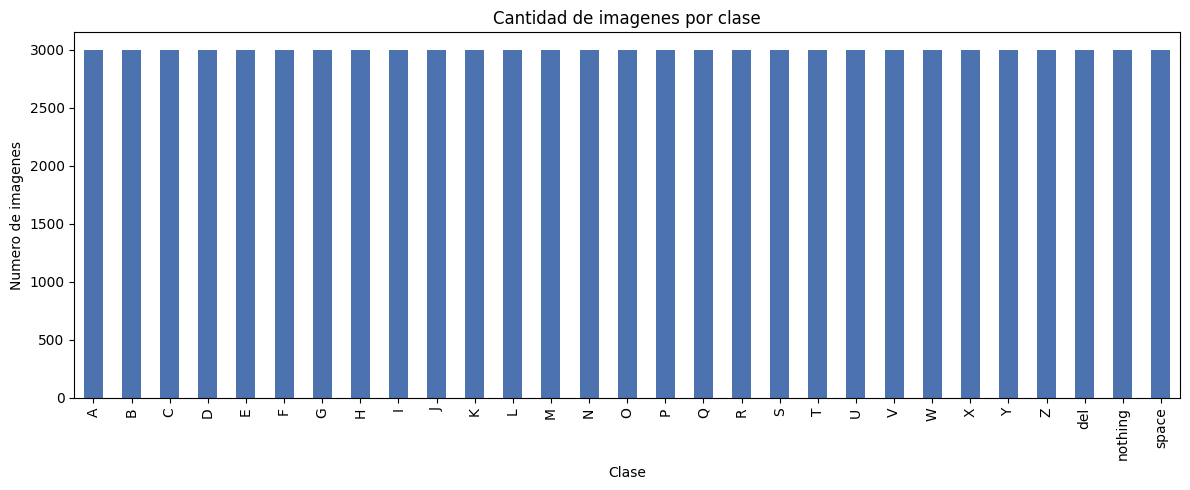

Minimo: 3000, Maximo: 3000, Promedio: 3000.0


In [3]:
plt.figure(figsize=(12, 5))
df_counts.plot(kind="bar", color="#4C72B0")
plt.title("Cantidad de imagenes por clase")
plt.ylabel("Numero de imagenes")
plt.xlabel("Clase")
plt.tight_layout()
plt.show()

print(f"Minimo: {df_counts.min()}, Maximo: {df_counts.max()}, Promedio: {df_counts.mean():.1f}")

In [4]:
# Revisar formato y resolucion en una muestra chica (no en las 87,000 imagenes)
sample_classes = random.sample(classes, 10)
info = []
for c in sample_classes:
    files = listar_archivos(TRAIN_DIR / c)
    for f in random.sample(files, 3):
        img = Image.open(TRAIN_DIR / c / f)
        info.append({
            "clase": c,
            "archivo": f,
            "tamano": img.size,
            "modo": img.mode,
            "extension": Path(f).suffix,
        })

df_info = pd.DataFrame(info)
df_info

,clase,archivo,tamano,modo,extension
0,U,U2134.jpg,"(200, 200)",RGB,.jpg
1,U,U1609.jpg,"(200, 200)",RGB,.jpg
2,U,U1873.jpg,"(200, 200)",RGB,.jpg
3,D,D2922.jpg,"(200, 200)",RGB,.jpg
4,D,D2077.jpg,"(200, 200)",RGB,.jpg
5,D,D955.jpg,"(200, 200)",RGB,.jpg
6,A,A2179.jpg,"(200, 200)",RGB,.jpg
7,A,A1048.jpg,"(200, 200)",RGB,.jpg
8,A,A1721.jpg,"(200, 200)",RGB,.jpg
9,X,X1402.jpg,"(200, 200)",RGB,.jpg


In [5]:
print("Tamaños únicos:", df_info["tamano"].unique())
print("Modos únicos:", df_info["modo"].unique())
print("Extensiones únicas:", df_info["extension"].unique())

Tamaños únicos: [(200, 200)]
Modos únicos: <StringArray>
['RGB']
Length: 1, dtype: str
Extensiones únicas: <StringArray>
['.jpg']
Length: 1, dtype: str


In [6]:
test_files = listar_archivos(TEST_DIR)
print(f"Imagenes en el test oficial: {len(test_files)}")
print(test_files[:10])

Imagenes en el test oficial: 28
['F_test.jpg', 'G_test.jpg', 'L_test.jpg', 'M_test.jpg', 'R_test.jpg', 'S_test.jpg', 'X_test.jpg', 'Y_test.jpg', 'U_test.jpg', 'T_test.jpg']


## Ejemplos de letras y variabilidad dentro de una clase

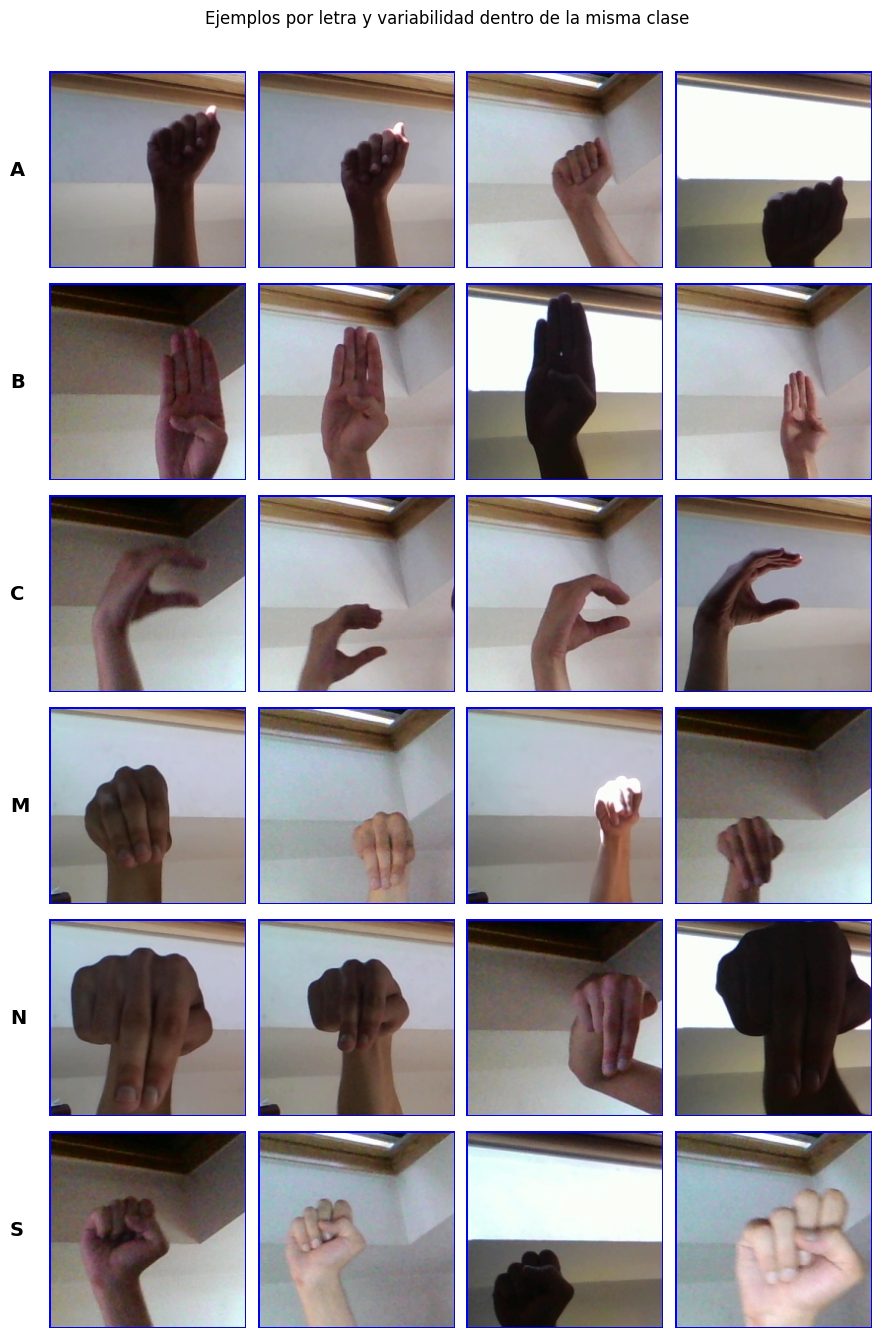

In [7]:
letras_ejemplo = ["A", "B", "C", "M", "N", "S"]
n_muestras = 4

fig, axes = plt.subplots(len(letras_ejemplo), n_muestras, figsize=(n_muestras * 2.2, len(letras_ejemplo) * 2.2))

for i, letra in enumerate(letras_ejemplo):
    files = listar_archivos(TRAIN_DIR / letra)
    muestra = random.sample(files, n_muestras)
    for j, f in enumerate(muestra):
        img = Image.open(TRAIN_DIR / letra / f)
        ax = axes[i, j]
        ax.imshow(img)
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(letra, rotation=0, labelpad=25, fontsize=12)
    axes[i, 0].text(-40, 100, letra, fontsize=14, weight="bold", va="center")

plt.suptitle("Ejemplos por letra y variabilidad dentro de la misma clase", y=1.01)
plt.tight_layout()
plt.show()

## Letras que se confunden visualmente

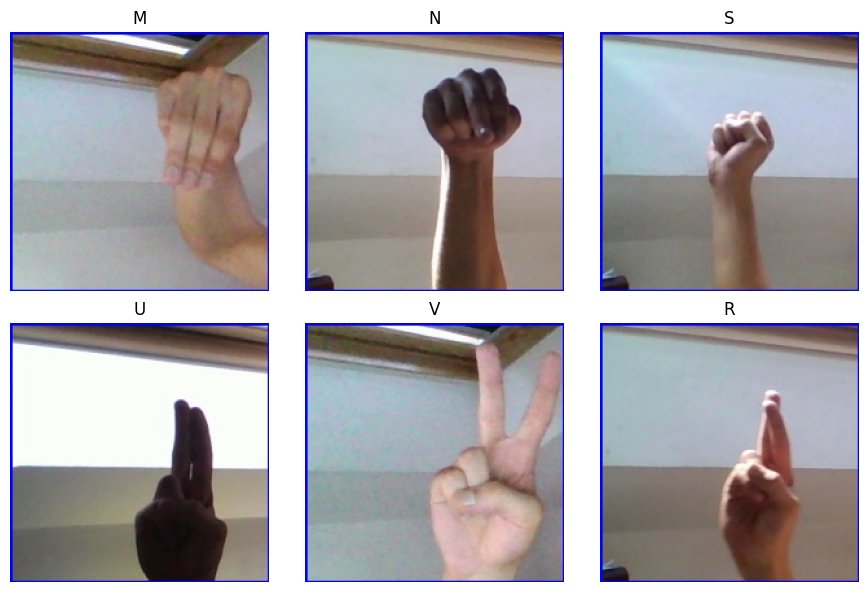

In [8]:
grupos_confusos = [["M", "N", "S"], ["U", "V", "R"]]

fig, axes = plt.subplots(len(grupos_confusos), 3, figsize=(9, 6))

for i, grupo in enumerate(grupos_confusos):
    for j, letra in enumerate(grupo):
        files = listar_archivos(TRAIN_DIR / letra)
        f = random.choice(files)
        img = Image.open(TRAIN_DIR / letra / f)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        axes[i, j].set_title(letra)

plt.tight_layout()
plt.show()

## Imagen promedio por clase

In [9]:
N_MUESTRA_PROMEDIO = 100

imagenes_promedio = {}
for c in classes:
    files = listar_archivos(TRAIN_DIR / c)
    muestra = random.sample(files, min(N_MUESTRA_PROMEDIO, len(files)))
    arreglos = np.stack([np.array(Image.open(TRAIN_DIR / c / f)) for f in muestra])
    imagenes_promedio[c] = arreglos.mean(axis=0).astype(np.uint8)

print(f"Imagen promedio calculada para {len(imagenes_promedio)} clases, con {N_MUESTRA_PROMEDIO} fotos cada una")

Imagen promedio calculada para 29 clases, con 100 fotos cada una


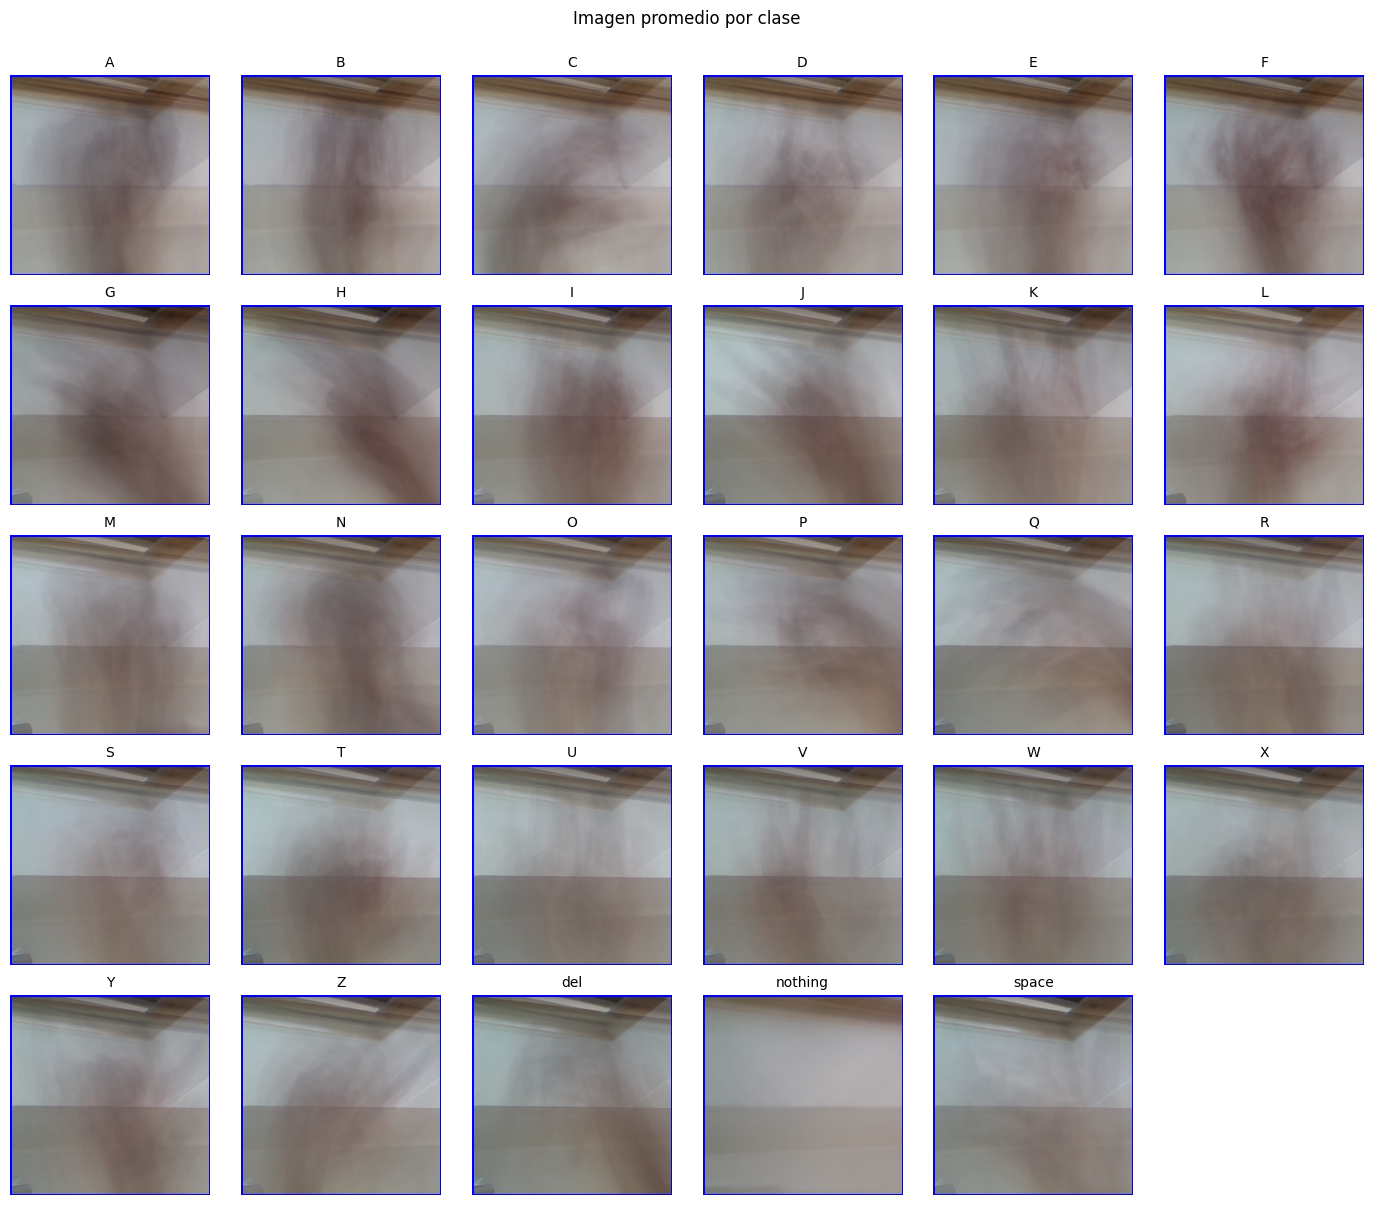

In [10]:
fig, axes = plt.subplots(5, 6, figsize=(14, 12))
axes = axes.flatten()

for ax, c in zip(axes, classes):
    ax.imshow(imagenes_promedio[c])
    ax.set_title(c, fontsize=10)
    ax.axis("off")

for ax in axes[len(classes):]:
    ax.axis("off")

plt.suptitle("Imagen promedio por clase", y=1.0)
plt.tight_layout()
plt.show()

## Heatmap de similitud entre clases

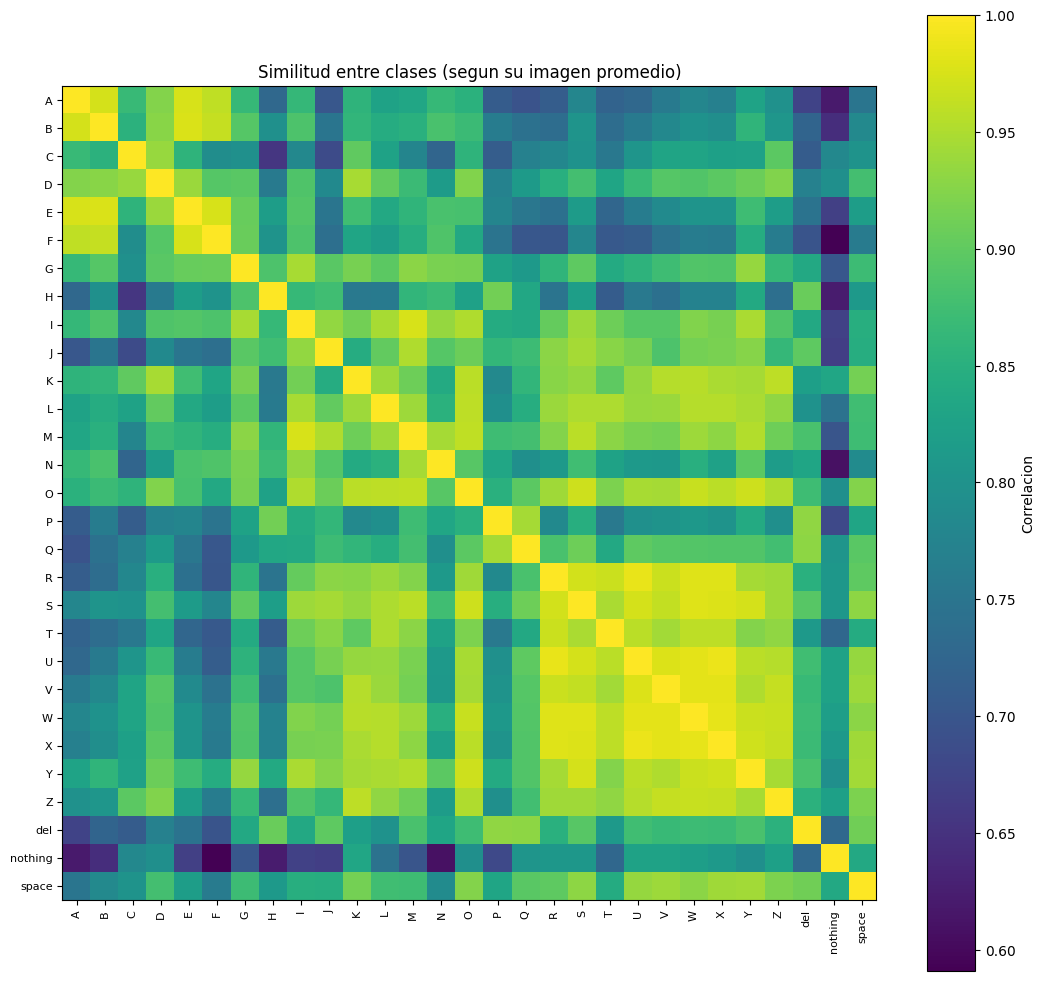

In [11]:
matriz = np.stack([imagenes_promedio[c].flatten().astype(float) for c in classes])
similitud = np.corrcoef(matriz)

fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(similitud, cmap="viridis")
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=90, fontsize=8)
ax.set_yticklabels(classes, fontsize=8)
plt.colorbar(im, label="Correlacion")
plt.title("Similitud entre clases (segun su imagen promedio)")
plt.tight_layout()
plt.show()

In [12]:
pares = []
for i in range(len(classes)):
    for j in range(i + 1, len(classes)):
        pares.append((classes[i], classes[j], similitud[i, j]))

df_pares = pd.DataFrame(pares, columns=["clase_1", "clase_2", "similitud"])
df_pares.sort_values("similitud", ascending=False).head(10)

,clase_1,clase_2,similitud
372,U,X,0.987568
342,R,U,0.985806
385,W,X,0.985231
378,V,W,0.982958
379,V,X,0.982698
371,U,W,0.982439
345,R,X,0.980058
344,R,W,0.979604
354,S,W,0.979274
370,U,V,0.978536


## Ejercicio 2 (parte final): division en train / validation / test

In [13]:
SAMPLE_PER_CLASS = 700

registros = []
for c in classes:
    files = listar_archivos(TRAIN_DIR / c)
    muestra = random.sample(files, min(SAMPLE_PER_CLASS, len(files)))
    for f in muestra:
        registros.append({"ruta": str(TRAIN_DIR / c / f), "clase": c})

df = pd.DataFrame(registros)
print(f"Total de imagenes en la submuestra: {len(df)}")
df["clase"].value_counts().sort_index()

Total de imagenes en la submuestra: 20300


clase
A          700
B          700
C          700
D          700
E          700
F          700
G          700
H          700
I          700
J          700
K          700
L          700
M          700
N          700
O          700
P          700
Q          700
R          700
S          700
T          700
U          700
V          700
W          700
X          700
Y          700
Z          700
del        700
nothing    700
space      700
Name: count, dtype: int64

In [14]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["clase"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["clase"], random_state=42
)

print(f"Train: {len(train_df)} imágenes")
print(f"Validation: {len(val_df)} imágenes")
print(f"Test: {len(test_df)} imágenes")

Train: 14210 imágenes
Validation: 3045 imágenes
Test: 3045 imágenes


In [15]:
# Guardar los manifiestos para que el resto del equipo los reutilice al entrenar
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

print("Manifiestos guardados: train_split.csv, val_split.csv, test_split.csv")

Manifiestos guardados: train_split.csv, val_split.csv, test_split.csv
